# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [5]:
# Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/nraja3.csv")
x = df["x"].to_numpy()
y = df["y"].to_numpy()
sigma = df["sigma_y"].to_numpy()

fit, cov = np.polyfit(x, y, 1, w=1/sigma, cov="unscaled")

m_naive = fit[0]
b_naive = fit[1]

m_err_naive = np.sqrt(cov[0, 0])
b_err_naive = np.sqrt(cov[1, 1])

y_model = m_naive * x + b_naive

residuals = y - y_model

chi2 = np.sum((residuals / sigma)**2)

dof = len(x) - 2

chi2_red = chi2 / dof

print(m_naive, "+/-", m_err_naive)
print(b_naive, "+/-", b_err_naive)
print(chi2_red)

4.216516357104667 +/- 0.11285734812207124
26.0047367353014 +/- 0.7075335334586212
39.64839301005501


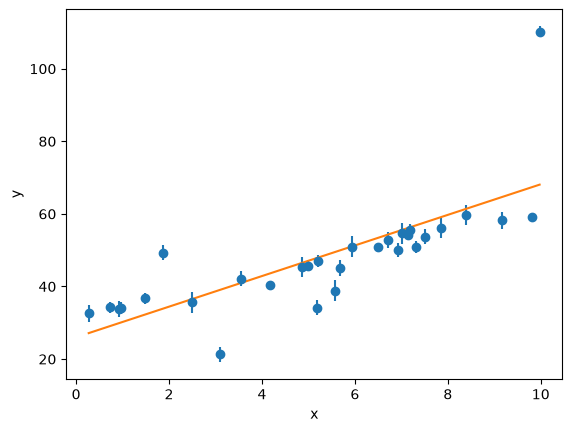

In [6]:
plt.errorbar(x, y, yerr=sigma, fmt="o")

plt.plot(x, m_naive*x + b_naive)

plt.xlabel("x")
plt.ylabel("y")

plt.show()

**ANSWER (a few sentences):**

*The reduced chi-squared is high, so the line is not fitting the data well. This is mainly because a few outliers are far away from the main trend and pull the fit in the wrong direction. I would not trust the error bars from this fit because the outliers cause the fit to slope up more*

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

In [27]:
mask = np.ones(len(x), dtype=bool)

for i in range(10):
    fit = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask])

    m = fit[0]
    b = fit[1]

    predicted_y = m * x + b
    residuals = y - predicted_y
    residuals_sigma = residuals / sigma
    new_mask = np.abs(residuals_sigma) < 3
    if np.all(new_mask == mask):
        break

    mask = new_mask

fit, cov = np.polyfit(
    x[mask],
    y[mask],
    1,
    w=1/sigma[mask],
    cov='unscaled'
)

m = fit[0]
b = fit[1]

m_error = np.sqrt(cov[0, 0])
b_error = np.sqrt(cov[1, 1])

outlier_fraction = np.sum(~mask) / len(mask)

print(m, "+/-", m_error)
print(b, "+/-", b_error)
print(outlier_fraction)

m_part2 = m
b_part2 = b
mask_part2 = mask.copy()

2.969707866270978 +/- 0.12346597397771938
31.1371802169869 +/- 0.7633882328657046
0.16666666666666666


In [28]:
m_values = []
b_values = []

for i in range(300):

    random_index = np.random.choice(len(x), len(x), replace=True)

    x_new = x[random_index]
    y_new = y[random_index]
    sigma_new = sigma[random_index]

    def mixture_new(values):

        m = values[0]
        b = values[1]
        f = values[2]
        bad_mean = values[3]
        bad_sigma = values[4]

        y_line = m*x_new + b

        good = norm.pdf(y_new, y_line, sigma_new)
        bad = norm.pdf(y_new, bad_mean, bad_sigma)

        good = (1-f)*good
        bad = f*bad

        probability = good + bad
        probability = probability + 1e-300
        log_probability = np.log(probability)

        total = np.sum(log_probability)

        return -total

    new_result = minimize(mixture_new, guess, bounds=bounds)

    new_m = new_result.x[0]
    new_b = new_result.x[1]

    m_values.append(new_m)
    b_values.append(new_b)


m_error_mix = np.std(m_values)
b_error_mix = np.std(b_values)

print(m_mix, "+/-", m_error_mix)
print(b_mix, "+/-", b_error_mix)
print(outlier_fraction_mix)

2.9543057938178268 +/- 0.13236166001115832
31.245098967085276 +/- 0.8665971946835114
0.18376627552327796


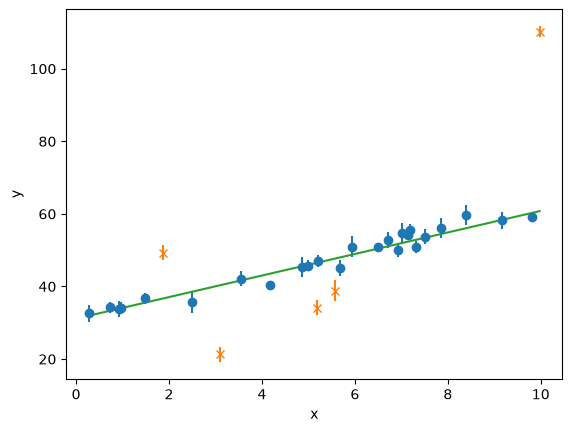

In [29]:
plt.errorbar(x[mask], y[mask], yerr=sigma[mask], fmt="o")
plt.errorbar(x[~mask], y[~mask], yerr=sigma[~mask], fmt="x")

plt.plot(x, m*x + b)

plt.xlabel("x")
plt.ylabel("y")

plt.show()

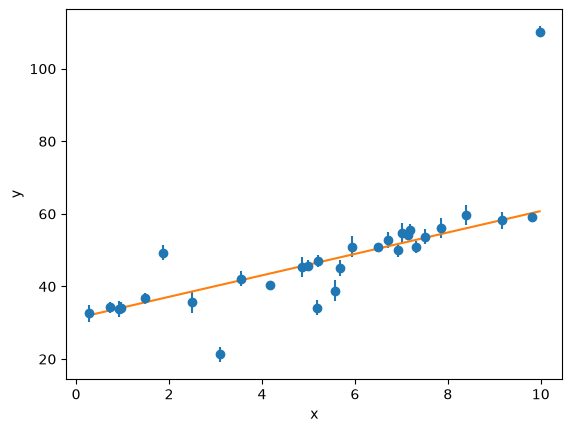

In [30]:
plt.errorbar(x, y, yerr=sigma, fmt="o")

plt.plot(x, m_mix*x + b_mix)

plt.xlabel("x")
plt.ylabel("y")

plt.show()

**FINAL ANSWER:** $m = $ 2.969707866270978 $\pm$ 0.12346597397771938, $b = $ 31.1371802169869
 $\pm$ 0.7633882328657046, outlier fraction $\approx$ 0.16666666666666666

**Justification and uncertainty method (a short paragraph):**

*I chose the sigma clipping fit because it gives a good fit after removing the points more than 3 sigma away from the fit. I used this because points more than 3 measurement uncertainties away are very much unlikely to belong to the main trend of the fit and the uncertainty values are slightly lower for when I used sigma-clipping compared to the mixture model. The uncertainties for the sigma-clipped fit come from the covariance matrix of the final weighted fit using the sigma_y values. The mixture model showed that about 18% of the points belong to the outlier population based on the outlier fraction. The fits for both seem to have similar slopes so I am confident in the slopes and intercept values but the sigm clipped model just has lower uncertainty values so I chose to answer using that model.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* It's supposed to perform weighted least squares, but the polyfit code has no weight, which means every point is treated equally. However, the sigma_y values are different, and the fit should be weighted by that.

*Flaw 2:* The contaminated residual standard deviation makes the clipping threshold so high that only one point is getting removed but there are more points that are many sigma away from the fit. 

*Flaw 3: Forcing reduced chi-squared to be equal 1 does not prove that the fit is good. 

In [32]:
# Part 3: demonstrations here

# Flaw 1:
fit_ai = np.polyfit(x, y, 1)

m_ai = fit_ai[0]
b_ai = fit_ai[1]

fit_weighted = np.polyfit(x, y, 1, w=1/sigma)

m_weighted = fit_weighted[0]
b_weighted = fit_weighted[1]

print("AI slope:", m_ai)
print("Weighted slope:", m_weighted)

print("AI intercept:", b_ai)
print("Weighted intercept:", b_weighted)

# Flaw 2:
fit_ai = np.polyfit(x, y, 1)

m_ai = fit_ai[0]
b_ai = fit_ai[1]

predicted_y = m_ai*x + b_ai

residuals = y - predicted_y

threshold = 3*np.std(residuals)

mask_ai = np.abs(residuals) < threshold

print("AI threshold:", threshold)
print("AI points removed:", np.sum(~mask_ai))
print("Part 2 points removed:", np.sum(~mask_part2))

# Flaw 3:
residuals = y[mask_ai] - (m2*x[mask_ai] + b2)

chi2 = np.sum((residuals / sigma[mask_ai])**2)

number_of_points = np.sum(mask_ai)

dof = number_of_points - 2

chi2_red = chi2 / dof

print("Reduced chi-squared before:", chi2_red)


scale = np.sqrt(chi2_red)

sigma_scaled = sigma * scale

chi2_new = np.sum(
    (residuals / sigma_scaled[mask_ai])**2
)

chi2_red_new = chi2_new / dof

print("Scale factor:", scale)
print("Reduced chi-squared after:", chi2_red_new)

residuals_part2 = y[mask_part2] - (m_part2*x[mask_part2] + b_part2)

chi2_part2 = np.sum(
    (residuals_part2 / sigma[mask_part2])**2
)

dof_part2 = np.sum(mask_part2) - 2

chi2_red_part2 = chi2_part2 / dof_part2

print("Part 2 reduced chi-squared:", chi2_red_part2)





AI slope: 4.076193296404234
Weighted slope: 4.216516357104667
AI intercept: 26.259738627320026
Weighted intercept: 26.0047367353014
AI threshold: 29.890021613541414
AI points removed: 1
Part 2 points removed: 5
Reduced chi-squared before: 6.5984198487243075
Scale factor: 2.5687389607985294
Reduced chi-squared after: 0.9999999999999998
Part 2 reduced chi-squared: 1.0401606458936343


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*I used ChatGPT. For the plotting parts of each lab questions I needed assistance remembering what lines of code to use so I would ask how "plt.errorbar" and what parameters it requires. I also had an error with the lines of code 
"probability = good + bad
log_probability = np.log(probability)"
due to some probabilities being so low that it gets rounded to 0 and np.log(0) gave me that error so I asked AI for a fix for that. In addition, I had struggle trying to understand how the mixture model worked so I had AI review that method and with how the code needed to be structured. AI helped me understand and code how to use bootstrap resampling for the mixture modeling.*

**VERIFICATION PLAN:**

*I compared the sigma-clipping and mixture-model fits. They gave very similar slopes and intercepts. This was one way that I verified that my numbers for part 2 were trustworthy. Also, plotting both lines showed that that the fits were obviously not being pulled towards the outliers using just basic observation and that the fit followed the main trend of the points. A faliure would be a fit that does not really follow the main trend of the points and would have been heavily affected by the outliers. I also checked that sigma clipping removed the obvious outliers and gave a reduced chi-squared close to 1 without artificially changing the measurement errors. A failure would have been a very large reduced chi-squared after clipping. I used bootstrap resampling for the mixture model to estimate how much the slope and intercept changed between samples. A failure would have been extremely large or unstable uncertainties.*